In [64]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore', category=UserWarning)


CRYPTO_MARKETS = [
    'eth_wbtc_usdc',
    'base_wbtc_usdt', # not ok
    'eth_cbbtc_usdc', 
    'eth_wbtc_usdt', # not ok
    "eth_wsteth_usdt",
    'eth_weth_usdt', # not ok 
    'eth_cbbtc_usdt', # not ok 
    'base_cbbtc_usdc_full',
    # 'base_wbtc_usdc',
    # 'base_wbtc_usdt',
]

PT_MARKETS = [
    'eth_PT-syrupUSDC-28AUG2025_usdc', 'eth_PT-slvlUSD-25SEP2025_usdc', 'eth_PT-USDe-27NOV2025_usds', 'eth_PT-USDe-25SEP2025_dai',
 'eth_PT-syrupUSDC-30OCT2025_usdc',
 'eth_PT-USDe-26DEC2024_usdc',
 'eth_PT-stcUSD-23JUL2026_usdc',
 'eth_PT-USDe-27NOV2025_usdc',
 'eth_PT-sNUSD-4JUN2026_usdc',
 'eth_PT-wstUSR-27MAR2025_usr',
 'eth_PT-mHYPER-29JAN2026_usdc',
 'eth_PT-sNUSD-5MAR2026_usdc',
 'eth_PT-lvlUSD-25SEP2025_usdc',
 'eth_PT-USD0++-31OCT2024_usdc',
 'eth_PT-USDe-31JUL2025_dai',
 'eth_PT-USDe-25SEP2025_usdt',
 'eth_PT-USDe-25SEP2025_usdc',
 'eth_PT-USR-4DEC2025_usdc',
 'eth_PT-wstUSR-27MAR2025_usdc',
 'eth_PT-USR-4SEP2025_usdc',
 'eth_PT-slvlUSD-29MAY2025_usdc',
 'eth_PT-mHYPER-20NOV2025_usdc',
 'eth_PT-syrupUSDC-18DEC2025_usdc',
 'eth_PT-sdeUSD-1753142406_usdc',
 'eth_PT-reUSD-25JUN2026_usdc',
 'eth_PT-USD0++-26JUN2025_usdc',
 'eth_PT-reUSD-18DEC2025_usdc',
 'eth_PT-RLP-4SEP2025_usdc',
 'eth_PT-csUSDL-31JUL2025_usdc',
 'eth_PT-mHYPER-30APR2026_usdc',
 'eth_PT-wstUSR-25SEP2025_usdc',
 'eth_PT-stcUSD-29JAN2026_usdc',
 'eth_PT-lvlUSD-29MAY2025_usdc',
 'eth_PT-USR-29MAY2025_usdc',
 'eth_PT-USDe-27MAR2025_dai',
 'eth_PT-csUSDL-30OCT2025_usdc',
 'eth_PT-RLP-9APR2026_usdc',
 'eth_PT-USD0++-27MAR2025_usdc']


YB_TOKENS = [
    'eth_usr_usdc', 'eth_wsteth_usdc', 'eth_rlp_usdc',
    'eth_usd0++_usdc', 'eth_fxsave_usdc', 'eth_mapollo_usdc',
    'eth_wsrusd_usdc', 'eth_syrupusdc_pyusd', 'eth_susde_pyusd',
    'eth_stcusd_usdc', 'eth_usde_dai', 'eth_mhyper_usdc', 'eth_syrupusdc_usdc',
    'eth_wstusr_usdc','eth_slvlusd_usdc','eth_csusdl_usdc', 'eth_mF-ONE_usdc', 'eth_reusd_usdc',
    'eth_siusd_usdc', 'eth_sdeusd_usdc'
]


pd.set_option("display.max_columns", 500)
# df = pd.concat([
#     pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/users_positions/crypto_tokens_positions.csv"),
#     pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/users_positions/pt_tokens_positions.csv"),
#     pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/users_positions/yb_tokens_positions.csv"),
# ], ignore_index=True)
df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/users_positions/pt_tokens_positions.csv")
df.loc[df['leverage_factor'] == 0, 'leverage_factor'] = 1
df = df[~df['market'].isin(['PT-reUSD-25JUN2026_usdc', 'PT-siUSD-26MAR2026_usdc'])]

mask = df['close_timestamp'].isna()
for market in df[mask]['market'].unique():
    market_max_ts = df[df['market'] == market]['open_timestamp'].max()
    market_max_dt = df[df['market'] == market]['open_datetime'].max()
    df.loc[(df['market'] == market) & mask, 'close_timestamp'] = market_max_ts
    df.loc[(df['market'] == market) & mask, 'close_datetime'] = market_max_dt

# Recalculate time-based fields for those rows
df.loc[mask, 'duration_hours'] = (df.loc[mask, 'close_timestamp'] - df.loc[mask, 'open_timestamp']) / 3600
df.loc[mask, 'time_to_first_action'] = df.loc[mask, 'duration_hours']  # assuming first action = open
df.loc[mask, 'avg_time_between_actions'] = df.loc[mask, 'duration_hours'] / df.loc[mask, 'n_actions_total'].clip(lower=1)
df.loc[mask, 'max_time_between_actions'] = df.loc[mask, 'duration_hours']  # approximation
df.loc[mask, 'time_to_first_action'] = df.loc[mask, 'duration_hours']
df.loc[mask, 'avg_time_between_actions'] = df.loc[mask, 'duration_hours']
df.loc[mask, 'max_time_between_actions'] = df.loc[mask, 'duration_hours']
df['avg_repay_ratio'] = 1

susp_opens = df.groupby(["user_address", "open_timestamp", "market"])['open_debt'].count()
susp_opens_addresses = susp_opens[susp_opens > 10].reset_index()['user_address'].unique()

print(susp_opens)

print("Before removing susp addrs", len(df), df['user_address'].nunique())
df = df[~df['user_address'].isin(susp_opens_addresses)]
print("After removing susp addrs", len(df), df['user_address'].nunique())

# Set closing fields to opening values for these rows
close_fields = ['close_debt', 'close_ltv', 'close_borrow_rate']
for field in close_fields:
    open_field = field.replace('close', 'open')
    df.loc[mask, field] = df.loc[mask, open_field]


user_address                                open_timestamp  market                       
0x0001D6E19ea317315dcD326a8B7918E8c42c7198  1.771939e+09    eth_PT-reUSD-25JUN2026_usdc      11
                                            1.772188e+09    eth_PT-reUSD-25JUN2026_usdc      11
                                            1.772353e+09    eth_PT-reUSD-25JUN2026_usdc      11
                                            1.772865e+09    eth_PT-reUSD-25JUN2026_usdc      11
                                            1.772918e+09    eth_PT-reUSD-25JUN2026_usdc      11
                                                                                             ..
0xfeF5e4Ebdb21Bec98F0Ae2cbecd5481bf21c133B  1.773242e+09    eth_PT-reUSD-25JUN2026_usdc      11
0xff17d5A9f7dB38A1384CF0ce1c81b880D17dB838  1.770558e+09    eth_PT-sNUSD-5MAR2026_usdc        2
0xff5167546b32789457355eA6d0BFF7506146Abc9  1.773327e+09    eth_PT-reUSD-25JUN2026_usdc      11
                                            1.

In [65]:
df[(df['user_address'] == '0x0001D6E19ea317315dcD326a8B7918E8c42c7198' ) & (df['market'] == 'eth_PT-reUSD-25JUN2026_usdc')]

,user_address,market,open_timestamp,open_datetime,open_debt,open_ltv,open_borrow_rate,leverage_factor,close_timestamp,close_datetime,close_debt,close_ltv,close_borrow_rate,max_debt,max_ltv,n_repays,n_borrows,is_closed,duration_hours,time_to_first_action,avg_time_between_actions,max_time_between_actions,n_actions_total,avg_repay_ratio,was_active_during_spike,num_spikes_experienced,closed_during_spike,position_size_share_open,position_size_share_max,debtors_rank,utilization_open,total_debt_open,total_liquidity_open,concentration_hhi_open,top3_share_open,avg_borrow_rate_position,n_liquidations,position_index,collateral_asset,loan_asset


In [66]:
df.head(10)

,user_address,market,open_timestamp,open_datetime,open_debt,open_ltv,open_borrow_rate,leverage_factor,close_timestamp,close_datetime,close_debt,close_ltv,close_borrow_rate,max_debt,max_ltv,n_repays,n_borrows,is_closed,duration_hours,time_to_first_action,avg_time_between_actions,max_time_between_actions,n_actions_total,avg_repay_ratio,was_active_during_spike,num_spikes_experienced,closed_during_spike,position_size_share_open,position_size_share_max,debtors_rank,utilization_open,total_debt_open,total_liquidity_open,concentration_hhi_open,top3_share_open,avg_borrow_rate_position,n_liquidations,position_index,collateral_asset,loan_asset
0,0x3B8DfE237895f737271371F339eEcbd66Face43e,eth_PT-RLP-4SEP2025_usdc,1.747986e+09,2025-05-23 07:45:35,0.099976,0.496911,0.125559,1.0,1.756649e+09,2025-08-31 13:58:47,0.099976,0.496911,0.125559,0.099976,0.496911,1.0,0.0,False,2406.220000,2406.220000,2406.220000,2406.220000,1.0,1,True,167.0,False,NaN,NaN,True,0.000000e+00,0.000000,0.000000,1.000000,100.000000,0.232085,0.0,0.0,PT-RLP-4SEP2025,usdc
1,0x3B8DfE237895f737271371F339eEcbd66Face43e,eth_PT-RLP-4SEP2025_usdc,1.747986e+09,2025-05-23 07:45:35,0.099976,0.496911,0.125559,1.0,1.756649e+09,2025-08-31 13:58:47,0.099976,0.496911,0.125559,0.099976,0.496911,1.0,1.0,False,2406.220000,2406.220000,2406.220000,2406.220000,2.0,1,True,167.0,False,NaN,NaN,True,0.000000e+00,0.000000,0.000000,1.000000,100.000000,0.232085,0.0,1.0,PT-RLP-4SEP2025,usdc
2,0x3B8DfE237895f737271371F339eEcbd66Face43e,eth_PT-RLP-4SEP2025_usdc,1.747986e+09,2025-05-23 07:45:35,0.099976,0.496911,0.125559,1.0,1.756649e+09,2025-08-31 13:58:47,0.099976,0.496911,0.125559,0.099976,0.496911,1.0,0.0,False,2406.220000,2406.220000,2406.220000,2406.220000,1.0,1,True,167.0,False,NaN,NaN,True,0.000000e+00,0.000000,0.000000,1.000000,100.000000,0.232085,0.0,2.0,PT-RLP-4SEP2025,usdc
3,0xFeffC588f4eA9c18A8B6CfB96e2EA9556BC516Fd,eth_PT-RLP-4SEP2025_usdc,1.748305e+09,2025-05-27 00:24:35,100575.036040,0.695526,0.012591,2.0,1.751254e+09,2025-06-30 03:24:23,54130.429379,0.458316,0.075793,336371.288992,0.761305,5.0,6.0,True,818.996667,0.053333,74.955333,496.890000,11.0,1,True,34.0,False,1.003748e+06,1.015087,True,2.666732e-07,0.100199,375738.658263,0.999999,100.000000,0.091866,0.0,3.0,PT-RLP-4SEP2025,usdc
4,0xFeffC588f4eA9c18A8B6CfB96e2EA9556BC516Fd,eth_PT-RLP-4SEP2025_usdc,1.748306e+09,2025-05-27 00:27:47,100575.036040,0.695526,0.023828,1.0,1.751254e+09,2025-06-30 03:24:23,54130.429379,0.458316,0.075793,336371.288992,0.761305,5.0,5.0,True,818.943333,0.140000,83.268148,496.890000,10.0,1,True,34.0,False,1.003748e+06,1.015087,True,2.666732e-07,0.100199,375738.658263,0.999999,99.999901,0.091866,0.0,4.0,PT-RLP-4SEP2025,usdc
5,0x3464a35D372aAC325783a0B19589055FAAB4fb5f,eth_PT-RLP-4SEP2025_usdc,1.748334e+09,2025-05-27 08:19:23,94851.857363,0.817257,0.048818,1.0,1.757058e+09,2025-09-05 07:38:35,40397.475802,0.687541,0.074146,307194.768169,0.817257,6.0,4.0,True,2423.320000,143.806667,253.271852,2243.280000,10.0,1,True,163.0,False,4.011561e-01,0.421651,True,6.292834e-01,236446.265892,139292.678269,0.999999,99.999970,0.094614,0.0,5.0,PT-RLP-4SEP2025,usdc
6,0x3464a35D372aAC325783a0B19589055FAAB4fb5f,eth_PT-RLP-4SEP2025_usdc,1.748334e+09,2025-05-27 08:19:23,94851.857363,0.817257,0.048818,1.0,1.757058e+09,2025-09-05 07:38:35,40397.475802,0.687541,0.074146,307194.768169,0.817257,6.0,4.0,True,2423.320000,143.806667,253.271852,2243.280000,10.0,1,True,163.0,False,4.011561e-01,0.421651,True,6.292834e-01,236446.265892,139292.678269,0.999999,99.999970,0.094614,0.0,6.0,PT-RLP-4SEP2025,usdc
7,0xd7Fc4Ab828AFc1bb4b217f337f1777Ca856Efd12,eth_PT-RLP-4SEP2025_usdc,1.748433e+09,2025-05-28 11:43:47,109975.580000,0.803604,0.197863,1.0,1.756974e+09,2025-09-04 08:26:23,162437.239918,0.794095,0.048395,647963.216273,1.011731,5.0,11.0,True,2372.710000,0.000000,158.180667,579.006667,16.0,1,True,157.0,False,3.318797e-01,0.096256,True,9.090488e-01,331371.773659,33154.072319,1.000000,99.999977,0.095194,0.0,7.0,PT-RLP-4SEP2025,usdc
8,0xd7Fc4Ab828AFc

In [67]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np

def parse_expiry_from_token(token_name):
    """Extract expiry datetime from a token string like PT-RLP-4SEP2025 or PT-USD0++-27MAR2025."""
    parts = token_name.split('-')
    for part in parts:
        if len(part) == 9 and part[:2].isdigit() and part[2:5].isalpha() and part[5:].isdigit():
            return datetime.strptime(part, '%d%b%Y')
    return None

def compute_max_concurrent(open_ts, close_ts):
    """Compute maximum number of overlapping intervals for a single user."""
    events = []
    for o, c in zip(open_ts, close_ts):
        if pd.isna(c):
            c = pd.Timestamp.now().timestamp()  # use current time for open positions
        events.append((o, 1))
        events.append((c, -1))
    events.sort(key=lambda x: x[0])
    current = 0
    max_con = 0
    for _, delta in events:
        current += delta
        if current > max_con:
            max_con = current
    return max_con

def aggregate_user_features(positions_df):
    """
    Aggregate position-level to user-level features for PT collateral markets,
    adding PT-specific features: time to expiry, near‑expiry closing, early opening,
    and YB-token diversity.

    Parameters
    ----------
    positions_df : pd.DataFrame, only PT market positions.

    Returns
    -------
    pd.DataFrame with one row per user_address.
    """
    df = positions_df.copy()

    # Ensure datetime columns
    df['open_datetime'] = pd.to_datetime(df['open_datetime'])
    df['close_datetime'] = pd.to_datetime(df['close_datetime'])

    # --- Parse PT-specific features ---
    # Extract token from market name (e.g., "eth_PT-RLP-4SEP2025_usdc" → "PT-RLP-4SEP2025")
    df['pt_token'] = df['market'].str.split('_').str[1]

    # Expiry date
    df['expiry_date'] = df['pt_token'].apply(parse_expiry_from_token)

    # Days between close and expiry; if not closed, set to 0 (as requested)
    df['days_to_expiry_after_close'] = np.where(
        df['is_closed'],
        (df['expiry_date'] - df['close_datetime']).dt.days,
        0
    )

    # Flag: closed within 7 days of expiry
    df['closed_near_expiry'] = df['is_closed'] & (df['days_to_expiry_after_close'] >= 0) & \
                               (df['days_to_expiry_after_close'] <= 7)

    # Early opening: within 14 days of the market's first position
    first_open_per_market = df.groupby('market')['open_datetime'].min().to_dict()
    df['first_open_market'] = df['market'].map(first_open_per_market)
    df['opened_early'] = (df['open_datetime'] <= df['first_open_market'] + timedelta(days=14))

    # YB token (e.g., "PT-RLP-4SEP2025" → "RLP")
    df['yb_token'] = df['pt_token'].str.split('-').str[1]

    # --- Original aggregations (adapted) ---
    df['effective_close_ltv'] = df.apply(
        lambda row: row['close_ltv'] if (row['is_closed'] and row['close_ltv'] > 0.5) else row['max_ltv'],
        axis=1
    )
    df['concentration_hhi_open_filled'] = df['concentration_hhi_open'].fillna(0.7)

    grouped = df.groupby('user_address')

    agg = grouped.agg(
        n_positions=('market', 'count'),
        n_markets=('market', 'nunique'),
        n_collateral_types=('collateral_asset', 'nunique'),
        n_loan_asset_types=('loan_asset', 'nunique'),

        mean_open_debt=('open_debt', 'mean'),
        median_open_debt=('open_debt', 'median'),
        mean_max_debt=('max_debt', 'mean'),
        median_max_debt=('max_debt', 'median'),
        max_debt=('max_debt', 'max'),

        median_max_ltv=('max_ltv', 'median'),
        mean_avg_borrow_rate=('avg_borrow_rate_position', 'mean'),

        mean_duration_hours=('duration_hours', 'mean'),
        median_duration_hours=('duration_hours', 'median'),
        mean_time_to_first_action=('time_to_first_action', 'mean'),
        median_time_to_first_action=('time_to_first_action', 'median'),

        avg_leverage_factor=('leverage_factor', 'mean'),

        mean_repays_per_pos=('n_repays', 'mean'),
        median_repays_per_pos=('n_repays', 'median'),
        total_repays=('n_repays', 'sum'),
        mean_borrows_per_pos=('n_borrows', 'mean'),
        median_borrows_per_pos=('n_borrows', 'median'),
        total_borrows=('n_borrows', 'sum'),

        mean_actions_per_pos=('n_actions_total', 'mean'),
        median_actions_per_pos=('n_actions_total', 'median'),
        total_actions=('n_actions_total', 'sum'),

        mean_avg_repay_ratio=('avg_repay_ratio', 'mean'),

        was_active_during_spike_any=('was_active_during_spike', 'any'),
        debtors_rank_ever=('debtors_rank', 'any'),

        mean_concentration_hhi=('concentration_hhi_open_filled', 'mean'),
        total_spikes=('num_spikes_experienced', 'sum'),

        prop_closed=('is_closed', 'mean'),
        prop_high_ltv_open=('open_ltv', lambda x: (x > 0.8).mean()),
        std_max_ltv=('max_ltv', 'std'),
        mean_max_share=('position_size_share_max', 'mean'),
        prop_debtors_rank=('debtors_rank', 'mean'),
        mean_utilization_open=('utilization_open', 'mean'),
        mean_total_liquidity_open=('total_liquidity_open', 'mean'),

        # --- New PT-specific aggregates ---
        mean_days_to_expiry=('days_to_expiry_after_close', 'mean'),
        median_days_to_expiry=('days_to_expiry_after_close', 'median'),
        prop_closed_near_expiry=('closed_near_expiry', 'mean'),
        prop_opened_early=('opened_early', 'mean'),
        n_yb_tokens=('yb_token', 'nunique')
    ).reset_index()

    # Effective close LTV
    eff_close = grouped['effective_close_ltv'].agg(['mean', 'median'])
    eff_close.columns = ['mean_effective_close_ltv', 'median_effective_close_ltv']
    agg = agg.merge(eff_close, on='user_address', how='left')

    # Overlap: max concurrent positions (unchanged)
    overlap_data = []
    for user, group in grouped:
        group = group.sort_values('open_timestamp')
        open_ts = group['open_timestamp'].values
        close_ts = group['close_timestamp'].values
        # treat open positions as still open (close = now)
        max_con = compute_max_concurrent(open_ts, close_ts)
        overlap_data.append({'user_address': user, 'max_concurrent_positions': max_con})
    overlap_df = pd.DataFrame(overlap_data)
    agg = agg.merge(overlap_df, on='user_address', how='left')
    agg['overlap_ratio'] = agg['max_concurrent_positions'] / agg['n_positions']

    # Std of borrow rates
    agg['std_avg_borrow_rate'] = grouped['avg_borrow_rate_position'].std().values
    agg['std_max_ltv'] = agg['std_max_ltv'].fillna(0)
    agg['std_avg_borrow_rate'] = agg['std_avg_borrow_rate'].fillna(0)

    return agg

In [68]:
users_features = aggregate_user_features(df)

In [69]:
users_features.head(5)

,user_address,n_positions,n_markets,n_collateral_types,n_loan_asset_types,mean_open_debt,median_open_debt,mean_max_debt,median_max_debt,max_debt,median_max_ltv,mean_avg_borrow_rate,mean_duration_hours,median_duration_hours,mean_time_to_first_action,median_time_to_first_action,avg_leverage_factor,mean_repays_per_pos,median_repays_per_pos,total_repays,mean_borrows_per_pos,median_borrows_per_pos,total_borrows,mean_actions_per_pos,median_actions_per_pos,total_actions,mean_avg_repay_ratio,was_active_during_spike_any,debtors_rank_ever,mean_concentration_hhi,total_spikes,prop_closed,prop_high_ltv_open,std_max_ltv,mean_max_share,prop_debtors_rank,mean_utilization_open,mean_total_liquidity_open,mean_days_to_expiry,median_days_to_expiry,prop_closed_near_expiry,prop_opened_early,n_yb_tokens,mean_effective_close_ltv,median_effective_close_ltv,max_concurrent_positions,overlap_ratio,std_avg_borrow_rate
0,0x002AFa1e35cE85272aAE5e0d7Ab541DFd442B667,2,1,1,1,1.579708e+04,1.579708e+04,1.579708e+04,1.579708e+04,1.579708e+04,0.851547,0.099236,662.270000,662.270000,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True,False,0.307859,36.0,1.0,1.0,0.0,0.000077,0.0,0.890883,2.527534e+07,9.0,9.0,0.0,0.0,1,0.843812,0.843812,2,1.0,0.0
1,0x00896485a15c549AA6948c7430bef1f02f752300,2,1,1,1,1.599523e+04,1.599523e+04,1.599523e+04,1.599523e+04,1.599523e+04,0.804415,0.094134,297.676667,297.676667,143.663333,143.663333,1.0,1.0,1.0,2.0,0.5,0.5,1.0,1.5,1.5,3.0,1.0,False,False,0.700000,0.0,1.0,0.0,0.0,0.070776,0.0,0.918699,2.000004e+04,50.0,50.0,0.0,1.0,1,0.803997,0.803997,2,1.0,0.0
2,0x008E5d9ea233Dfb9AB48098d6E98E14374030c15,2,1,1,1,1.689294e+05,1.689294e+05,9.847084e+05,9.847084e+05,9.847084e+05,0.857420,0.057556,1837.820000,1837.820000,0.045000,0.045000,14.0,29.0,29.0,58.0,14.5,14.5,29.0,43.5,43.5,87.0,1.0,True,True,1.000000,54.0,1.0,1.0,0.0,0.622500,1.0,0.696064,7.598600e+06,-1.0,-1.0,0.0,0.0,1,0.628643,0.628643,2,1.0,0.0
3,0x00A2913501C4B09B92b825dC8A2937eFDaD9953b,2,1,1,1,4.999480e+05,4.999480e+05,7.298244e+06,7.298244e+06,7.298244e+06,0.797200,0.145384,1755.310000,1755.310000,10.883333,10.883333,1.0,8.0,8.0,16.0,8.0,8.0,16.0,16.0,16.0,32.0,1.0,True,True,1.000002,154.0,1.0,0.0,0.0,0.498799,1.0,0.934287,9.279599e+05,-2.0,-2.0,0.0,1.0,1,0.718067,0.718067,2,1.0,0.0
4,0x00B8dF76c223eb4b05123389330b4afD157152b8,2,1,1,1,1.238581e+06,1.238581e+06,4.760966e+06,4.760966e+06,4.760966e+06,0.890971,0.052546,437.876667,437.876667,0.076667,0.076667,4.0,5.0,5.0,10.0,4.5,4.5,9.0,9.5,9.5,19.0,1.0,True,True,0.688498,20.0,1.0,1.0,0.0,1.741203,1.0,0.368415,4.687495e+06,-1.0,-1.0,0.0,0.0,1,0.854283,0.854283,2,1.0,0.0


In [70]:
users_features['median_max_debt'].describe()
users_features[users_features['median_max_debt']>1_000_000].shape

(188, 48)

In [71]:
def prepare_user_features_for_clustering(user_df, 
                                         cap_lower=0.005, cap_upper=0.995):
    import numpy as np
    import pandas as pd
    from sklearn.preprocessing import StandardScaler

    df = user_df.copy()

    # 1. Selected features for clustering
    behavioral = [
        # 'median_max_ltv',
        'mean_effective_close_ltv',
        'mean_avg_borrow_rate',
        'avg_leverage_factor',
        'mean_repays_per_pos',
        'mean_borrows_per_pos',
        'mean_actions_per_pos',
        # 'mean_avg_repay_ratio',
        # 'prop_high_ltv_open',
        # 'prop_closed'
    ]
    time_features = [
        'mean_duration_hours',
        # 'mean_time_to_first_action',
        'overlap_ratio'
    ]
    market_breadth = [
        'n_markets',
        # 'n_collateral_types',
        # 'n_loan_asset_types',
        # 'n_positions',
        # 'max_concurrent_positions'
    ]
    risk_spike = [
        # 'was_active_during_spike_any',
        'total_spikes',
        # 'debtors_rank_ever'
    ]
    size_features = [
        'mean_max_share'
    ]
    debt_features = [
        # 'median_open_debt', 
        # 'median_max_debt',
        'max_debt'
    ]
    pt_specific = [
        'mean_days_to_expiry',
        'prop_closed_near_expiry',
        'prop_opened_early',
        'n_yb_tokens',
    ]

    df["large_max_debt"] = df["max_debt"] > 1_000_000

    # Optionally add market type flags
    # flags = ['has_crypto', 'has_pt', 'has_yb', "large_max_debt"]
    flags = ["large_max_debt"]

    selected_features = (behavioral + time_features + market_breadth +
                         risk_spike + size_features + flags + debt_features + pt_specific)

    # Ensure all exist, drop missing
    missing = set(selected_features) - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in user_df: {missing}")
    X = df[selected_features].copy()

    from sklearn.preprocessing import QuantileTransformer
    qt = QuantileTransformer(output_distribution='normal', random_state=42)
    X[debt_features] = qt.fit_transform(X[debt_features].fillna(0))


    # 2. Handle NaNs - impute with median (should be rare)
    for col in X.columns:
        if X[col].isna().any():
            if X[col].dtype == 'bool':
                X[col].fillna(False, inplace=True)
            else:
                X[col].fillna(X[col].median(), inplace=True)

    # 3. Log transform skewed non-negative variables
    log_features = [
        'n_markets', 'n_collateral_types', 'n_loan_asset_types',
        'n_positions', 'max_concurrent_positions',
        # 'median_open_debt', 'median_max_debt', 
        # 'mean_max_share',
        'mean_duration_hours', 'mean_time_to_first_action',
        'total_spikes'  # count, often skewed
    ]
    # Ensure we only log-transform columns that exist
    log_features = [f for f in log_features if f in X.columns]
    for col in log_features:
        X[col] = np.log1p(X[col].clip(lower=0))  # clip to avoid negative from error

    # 4. Winsorize all features to [cap_lower, cap_upper]
    for col in X.columns:
        try:
            lower = X[col].quantile(cap_lower)
            upper = X[col].quantile(cap_upper)
            X[col] = X[col].clip(lower, upper)
        except Exception as e:
            continue

    # 5. Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, selected_features, scaler

X_scaled, selected_features, scaler = prepare_user_features_for_clustering(users_features)

/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_76180/127377434.py:80: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)
/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_76180/127377434.py:80: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

In [72]:
X_scaled.shape

(1622, 17)

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import hdbscan

def calc_clustering_quality(labels, X_scaled):
    """
    Calculate clustering quality metrics.
    """
    labels = np.asarray(labels)
    core_mask = labels != -1
    
    if core_mask.sum() <= 2 or len(np.unique(labels[core_mask])) <= 1:
        return {
            'n_clusters': 0,
            'noise_ratio': np.mean(labels == -1),
            'silhouette': np.nan,
            'davies_bouldin': np.nan,
            'calinski_harabasz': np.nan
        }
    
    X_core = X_scaled[core_mask]
    labels_core = labels[core_mask]
    
    return {
        'n_clusters': len(np.unique(labels_core)),
        'noise_ratio': np.mean(labels == -1),
        'silhouette': silhouette_score(X_core, labels_core),
        'davies_bouldin': davies_bouldin_score(X_core, labels_core),
        'calinski_harabasz': calinski_harabasz_score(X_core, labels_core)
    }

def run_hdbscan(X_scaled, min_cluster_size=10, min_samples=None, metric='euclidean'):
    """
    Run HDBSCAN clustering on scaled features.

    Returns
    -------
    labels : np.ndarray
        Cluster labels ( -1 for noise).
    clusterer : hdbscan.HDBSCAN
        Fitted HDBSCAN object.
    """
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric=metric,
        gen_min_span_tree=True
    )
    labels = clusterer.fit_predict(X_scaled)
    return labels, clusterer


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

def run_kmeans(X_scaled, n_clusters=8, random_state=42, n_init=10):
    """
    Run KMeans clustering on scaled features.

    Returns
    -------
    labels : np.ndarray
        Integer cluster labels (0 .. n_clusters-1).
    model : KMeans
        Fitted KMeans object.
    """
    model = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=n_init
    )
    labels = model.fit_predict(X_scaled)
    return labels, model
def evaluate_clustering(labels, X_scaled, user_df, feature_names,
                        plot_features=None, figsize=(14, 10)):
    """
    Evaluate clustering results: print scores, PCA scatter, and boxplots of features per cluster.

    Parameters
    ----------
    labels : array-like
        Cluster labels from any clustering method (-1 for noise).
    X_scaled : np.ndarray
        Scaled feature matrix used for clustering (same order as user_df).
    user_df : pd.DataFrame
        Original user-level DataFrame (same index order as X_scaled).
    feature_names : list
        Names of the features used for clustering (columns of X_scaled).
    plot_features : list, optional
        Features to display in boxplots; defaults to the first 12 features.
    figsize : tuple
        Figure size for PCA plot.

    Returns
    -------
    df_with_labels : pd.DataFrame
        Copy of user_df with an added 'cluster' column (noise excluded).
    """
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels[unique_labels >= 0])
    n_noise = np.sum(labels == -1)
    noise_ratio = n_noise / len(labels)

    print("=" * 60)
    print("HDBSCAN Clustering Evaluation")
    print(f"  Number of clusters (excluding noise): {n_clusters}")
    print(f"  Noise points: {n_noise} ({noise_ratio:.1%})")
    print("  Cluster sizes:")
    for lab in sorted(unique_labels):
        if lab == -1:
            continue
        count = np.sum(labels == lab)
        print(f"    Cluster {lab}: {count} users ({count/len(labels):.1%})")

    # Validation metrics on core (non-noise) points
    core_mask = labels != -1
    if core_mask.sum() > 1 and n_clusters > 1:
        X_core = X_scaled[core_mask]
        labels_core = labels[core_mask]
        sil = silhouette_score(X_core, labels_core)
        db = davies_bouldin_score(X_core, labels_core)
        ch = calinski_harabasz_score(X_core, labels_core)
        metrics = {
            "silhouette_score": sil,
            "DB_score": db,
            "CH_score": ch,
        }
        print(f"  Silhouette Score (core): {sil:.4f}")
        print(f"  Davies-Bouldin Score (core): {db:.4f}")
        print(f"  Calinski-Harabasz Score (core): {ch:.2f}")
    else:
        print("  Not enough clusters or core points for validation scores.")

    # PCA scatter plot
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    plt.figure(figsize=(8, 6))
    if n_noise > 0:
        plt.scatter(X_pca[labels == -1, 0], X_pca[labels == -1, 1],
                    c='grey', marker='x', alpha=0.5, label='Noise')
    for lab in sorted(unique_labels):
        if lab == -1:
            continue
        mask = labels == lab
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {lab}', alpha=0.7, s=30)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    plt.title('PT collateral tokens -- HDBSCAN Clusters (PCA projection)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Boxplots of selected features per cluster
    if plot_features is None:
        plot_features = feature_names[:min(12, len(feature_names))]

    df_plot = user_df.copy()
    df_plot['cluster'] = labels
    df_plot = df_plot[df_plot['cluster'] != -1]  # exclude noise

    if len(df_plot) == 0:
        print("No non-noise points to plot.")
        return df_plot

    df_melt = df_plot.melt(id_vars='cluster', value_vars=plot_features,
                           var_name='Feature', value_name='Value')
    g = sns.catplot(data=df_melt, x='cluster', y='Value',
                    col='Feature', col_wrap=4, kind='box',
                    sharey=False, height=3, aspect=1.2)
    g.fig.suptitle('Feature Distributions Across Clusters', fontsize=14)
    g.fig.subplots_adjust(top=0.9)
    g.set_xticklabels(rotation=45)
    plt.show()

    return df_plot

In [81]:
hdbscan_labels, hdbscan_clusterer = run_hdbscan(
    X_scaled,
    min_cluster_size=50,
    min_samples=10
)

user_clusters_to_save = users_features.copy()[["user_address"]]
user_clusters_to_save['cluster'] = hdbscan_labels

user_clusters_to_save['cluster'].value_counts()
user_clusters_to_save.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/pt_users_clusters_mapping.csv", index=False)


In [75]:
from tqdm import tqdm_notebook
metrics_hist = {}
for mc in tqdm_notebook([10, 20, 30, 40, 50, 75, 100]):
    hdbscan_labels, hdbscan_clusterer = run_hdbscan(
        X_scaled,
        min_cluster_size=mc,
        min_samples=10
    )
    metrics_hist[mc] = {
        "labels": hdbscan_labels,
        "metrics": calc_clustering_quality(hdbscan_labels, X_scaled),
        "cluster_sizes": list(pd.Series(hdbscan_labels).value_counts())
    }
for k in metrics_hist.keys():
    print(k, metrics_hist[k]['metrics'])

/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_76180/1829689340.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for mc in tqdm_notebook([10, 20, 30, 40, 50, 75, 100]):


  0%|          | 0/7 [00:00<?, ?it/s]

10 {'n_clusters': 9, 'noise_ratio': 0.27805178791615287, 'silhouette': 0.2779003451689367, 'davies_bouldin': 1.1573327941240312, 'calinski_harabasz': 129.11235817032835}
20 {'n_clusters': 7, 'noise_ratio': 0.29531442663378543, 'silhouette': 0.28167933332987416, 'davies_bouldin': 1.1826945475127564, 'calinski_harabasz': 155.37181195935642}
30 {'n_clusters': 5, 'noise_ratio': 0.2712700369913687, 'silhouette': 0.2602161544242997, 'davies_bouldin': 1.3838510707222196, 'calinski_harabasz': 179.3523148827485}
40 {'n_clusters': 5, 'noise_ratio': 0.2712700369913687, 'silhouette': 0.2602161544242997, 'davies_bouldin': 1.3838510707222196, 'calinski_harabasz': 179.3523148827485}
50 {'n_clusters': 4, 'noise_ratio': 0.3008631319358816, 'silhouette': 0.25550211376936166, 'davies_bouldin': 1.4705769533898814, 'calinski_harabasz': 190.0139805266696}
75 {'n_clusters': 4, 'noise_ratio': 0.3008631319358816, 'silhouette': 0.25550211376936166, 'davies_bouldin': 1.4705769533898814, 'calinski_harabasz': 190.

In [34]:
metrics_hist1 = {}
for k in [3, 4, 5, 6, 7, 8, 9, 10, 12, 15]:
    kmeans_labels, kmeans_model = run_kmeans(
        X_scaled,
        n_clusters=k,
        random_state=42,
        n_init=5
    )
    metrics_hist1[k] = {
        "labels": kmeans_labels,
        "metrics": calc_clustering_quality(kmeans_labels, X_scaled),
        "cluster_sizes": list(pd.Series(kmeans_labels).value_counts())
    }

# Print results
for k in metrics_hist1.keys():
    print(f"k={k}: {metrics_hist1[k]['metrics']}")


k=3: {'n_clusters': 3, 'noise_ratio': 0.0, 'silhouette': 0.28441515145588364, 'davies_bouldin': 1.6841110620276674, 'calinski_harabasz': 304.36655341922864}
k=4: {'n_clusters': 4, 'noise_ratio': 0.0, 'silhouette': 0.170290613472953, 'davies_bouldin': 1.991853608091906, 'calinski_harabasz': 253.595827649238}
k=5: {'n_clusters': 5, 'noise_ratio': 0.0, 'silhouette': 0.1681598162995708, 'davies_bouldin': 1.8732965890427014, 'calinski_harabasz': 222.77794473260423}
k=6: {'n_clusters': 6, 'noise_ratio': 0.0, 'silhouette': 0.16936007387498783, 'davies_bouldin': 1.8692067645314754, 'calinski_harabasz': 203.28248499490044}
k=7: {'n_clusters': 7, 'noise_ratio': 0.0, 'silhouette': 0.16564399277847625, 'davies_bouldin': 1.7945397758258967, 'calinski_harabasz': 194.445636650291}
k=8: {'n_clusters': 8, 'noise_ratio': 0.0, 'silhouette': 0.15007296977099985, 'davies_bouldin': 1.728686976397759, 'calinski_harabasz': 190.606320396276}
k=9: {'n_clusters': 9, 'noise_ratio': 0.0, 'silhouette': 0.1717281670

In [35]:
for k in metrics_hist.keys():
    print(k, metrics_hist[k]['metrics'])

10 {'n_clusters': 10, 'noise_ratio': 0.3810110974106042, 'silhouette': 0.25761550645106607, 'davies_bouldin': 1.1521590892561702, 'calinski_harabasz': 112.80181610588728}
20 {'n_clusters': 6, 'noise_ratio': 0.46732429099876693, 'silhouette': 0.270291032279304, 'davies_bouldin': 1.1644868576426053, 'calinski_harabasz': 145.45395669589595}
30 {'n_clusters': 4, 'noise_ratio': 0.5098643649815043, 'silhouette': 0.2860586315020382, 'davies_bouldin': 1.236581959055362, 'calinski_harabasz': 200.30824929028745}
40 {'n_clusters': 4, 'noise_ratio': 0.5480887792848336, 'silhouette': 0.30506208132255713, 'davies_bouldin': 1.1536427755329595, 'calinski_harabasz': 194.23289232080649}
50 {'n_clusters': 4, 'noise_ratio': 0.5721331689272503, 'silhouette': 0.31757770684777764, 'davies_bouldin': 1.1139708111846858, 'calinski_harabasz': 189.0260962706166}
75 {'n_clusters': 0, 'noise_ratio': 1.0, 'silhouette': nan, 'davies_bouldin': nan, 'calinski_harabasz': nan}
100 {'n_clusters': 0, 'noise_ratio': 1.0, 's

HDBSCAN Clustering Evaluation
  Number of clusters (excluding noise): 5
  Noise points: 440 (27.1%)
  Cluster sizes:
    Cluster 0: 48 users (3.0%)
    Cluster 1: 75 users (4.6%)
    Cluster 2: 117 users (7.2%)
    Cluster 3: 746 users (46.0%)
    Cluster 4: 196 users (12.1%)
  Silhouette Score (core): 0.2602
  Davies-Bouldin Score (core): 1.3839
  Calinski-Harabasz Score (core): 179.35


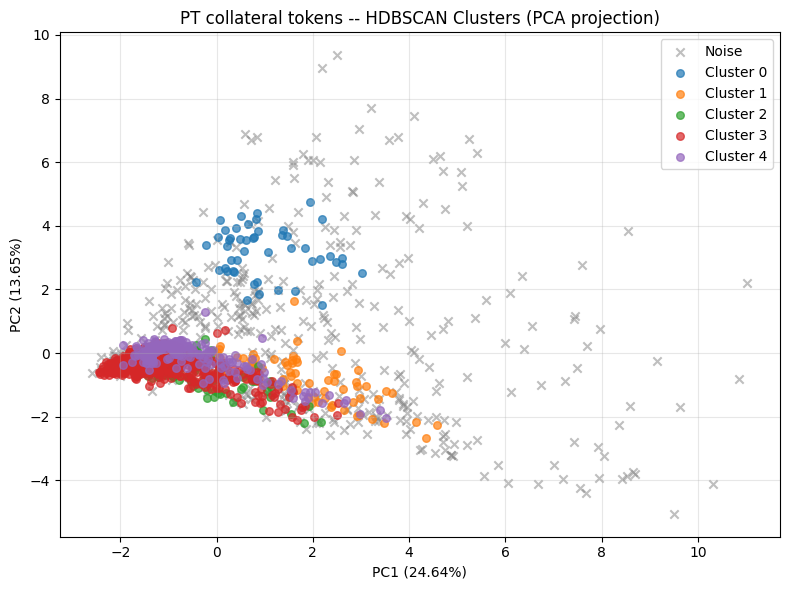

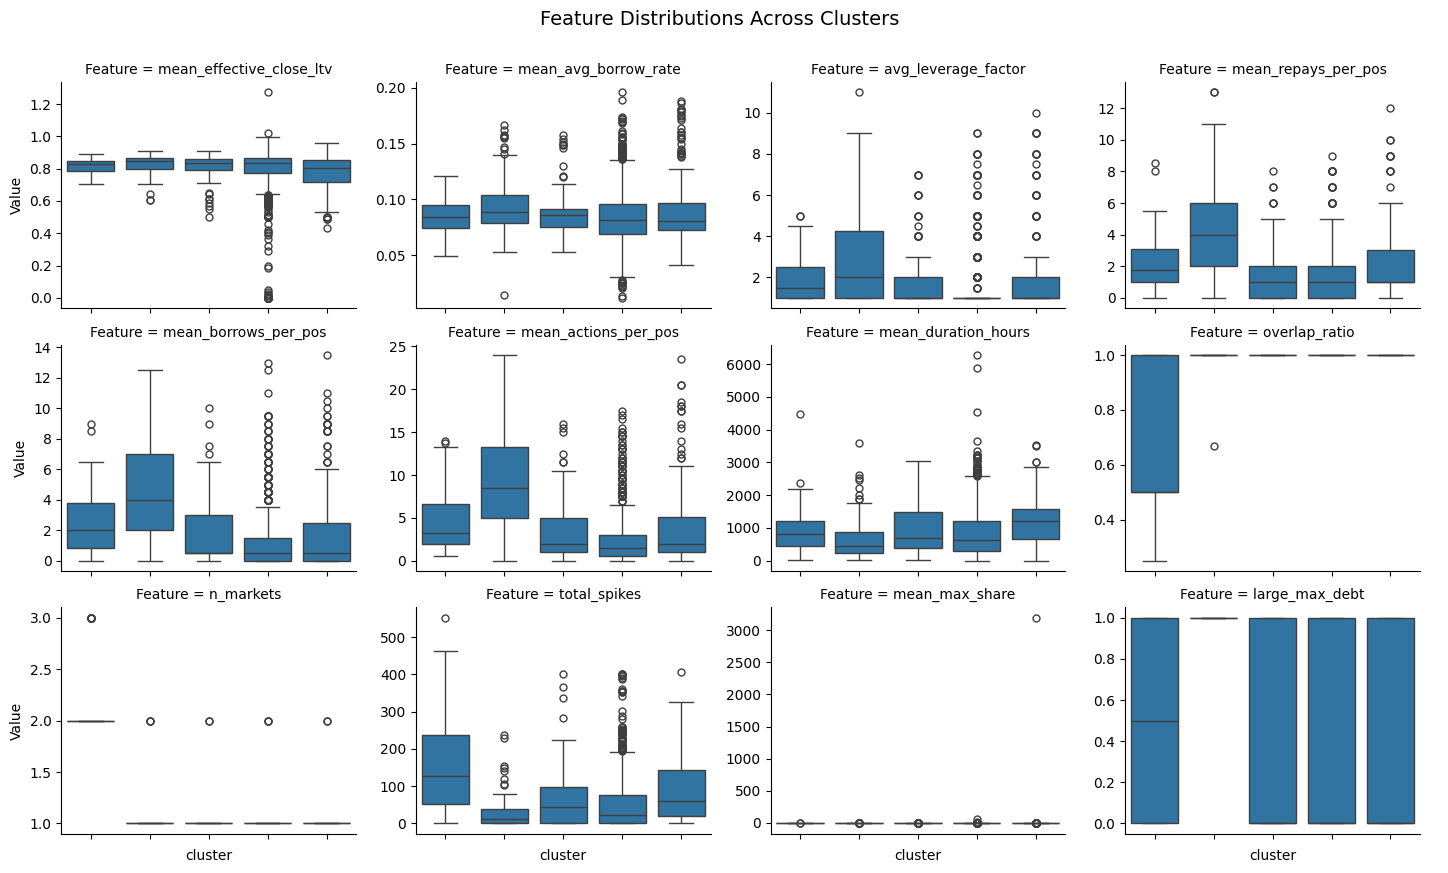

,user_address,n_positions,n_markets,n_collateral_types,n_loan_asset_types,mean_open_debt,median_open_debt,mean_max_debt,median_max_debt,max_debt,median_max_ltv,mean_avg_borrow_rate,mean_duration_hours,median_duration_hours,mean_time_to_first_action,median_time_to_first_action,avg_leverage_factor,mean_repays_per_pos,median_repays_per_pos,total_repays,mean_borrows_per_pos,median_borrows_per_pos,total_borrows,mean_actions_per_pos,median_actions_per_pos,total_actions,mean_avg_repay_ratio,was_active_during_spike_any,debtors_rank_ever,mean_concentration_hhi,total_spikes,prop_closed,prop_high_ltv_open,std_max_ltv,mean_max_share,prop_debtors_rank,mean_utilization_open,mean_total_liquidity_open,mean_days_to_expiry,median_days_to_expiry,prop_closed_near_expiry,prop_opened_early,n_yb_tokens,mean_effective_close_ltv,median_effective_close_ltv,max_concurrent_positions,overlap_ratio,std_avg_borrow_rate,large_max_debt,cluster
0,0x002AFa1e35cE85272aAE5e0d7Ab541DFd442B667,2,1,1,1,1.579708e+04,1.579708e+04,1.579708e+04,1.579708e+04,1.579708e+04,0.851547,0.099236,662.270000,662.270000,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True,False,0.307859,36.0,1.0,1.0,0.0,0.000077,0.0,0.890883,2.527534e+07,9.0,9.0,0.0,0.0,1,0.843812,0.843812,2,1.0,0.0,False,3
1,0x00896485a15c549AA6948c7430bef1f02f752300,2,1,1,1,1.599523e+04,1.599523e+04,1.599523e+04,1.599523e+04,1.599523e+04,0.804415,0.094134,297.676667,297.676667,143.663333,143.663333,1.0,1.0,1.0,2.0,0.5,0.5,1.0,1.5,1.5,3.0,1.0,False,False,0.700000,0.0,1.0,0.0,0.0,0.070776,0.0,0.918699,2.000004e+04,50.0,50.0,0.0,1.0,1,0.803997,0.803997,2,1.0,0.0,False,4
3,0x00A2913501C4B09B92b825dC8A2937eFDaD9953b,2,1,1,1,4.999480e+05,4.999480e+05,7.298244e+06,7.298244e+06,7.298244e+06,0.797200,0.145384,1755.310000,1755.310000,10.883333,10.883333,1.0,8.0,8.0,16.0,8.0,8.0,16.0,16.0,16.0,32.0,1.0,True,True,1.000002,154.0,1.0,0.0,0.0,0.498799,1.0,0.934287,9.279599e+05,-2.0,-2.0,0.0,1.0,1,0.718067,0.718067,2,1.0,0.0,True,1
4,0x00B8dF76c223eb4b05123389330b4afD157152b8,2,1,1,1,1.238581e+06,1.238581e+06,4.760966e+06,4.760966e+06,4.760966e+06,0.890971,0.052546,437.876667,437.876667,0.076667,0.076667,4.0,5.0,5.0,10.0,4.5,4.5,9.0,9.5,9.5,19.0,1.0,True,True,0.688498,20.0,1.0,1.0,0.0,1.741203,1.0,0.368415,4.687495e+06,-1.0,-1.0,0.0,0.0,1,0.854283,0.854283,2,1.0,0.0,True,1
5,0x00C4F3705B36dB52A074a2D14D167EbF4804452a,2,1,1,1,2.098773e+04,2.098773e+04,4.205824e+04,4.205824e+04,4.205824e+04,0.815947,0.102052,1005.456667,1005.456667,0.046667,0.046667,2.0,5.0,5.0,10.0,3.0,3.0,6.0,8.0,8.0,16.0,1.0,True,False,0.523670,180.0,1.0,0.0,0.0,0.008266,0.0,0.929396,3.839172e+05,NaN,NaN,0.0,0.0,1,0.771031,0.771031,2,1.0,0.0,False,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617,0xfc9803f19a667Ac43E13fC57405f9fDCdaC54747,2,1,1,1,1.299721e+04,1.299721e+04,1.499973e+04,1.499973e+04,1.499973e+04,1.272642,0.075387,387.983333,387.983333,248.103333,248.103333,1.0,1.0,1.0,2.0,2.0,2.0,4.0,3.0,3.0,6.0,1.0,True,False,0.616618,16.0,1.0,1.0,0.0,0.002204,0.0,0.891826,8.900126e+05,NaN,NaN,0.0,0.0,1,1.272642,1.272642,2,1.0,0.0,False,3
1618,0xfcB2f00cF544E934E2f163c2593c7CE3eF7fFA9D,2,1,1,1,1.399968e+05,1.399968e+05,1.399968e+05,1.399968e+05,1.399968e+05,0.867930,0.061129,132.886667,132.886667,66.413333,66.413333,1.0,2.0,2.0,4.0,0.5,0.5,1.0,2.5,2.5,5.0,1.0,True,True,0.949284,16.0,1.0,1.0,0.0,0.317168,1.0,0.867609,6.735403e+04,135.0,135.0,0.0,0.0,1,0.867930,0.867930,2,1.0,0.0,True,3
1619,0xfd1fA2C22F65649AE02188a33F286f22bcFCd225,2,1,1,1,4.490104e+04,4.490104e+04,9.136159e+04,9.136159e+04,9.136159e+04,0.903065,0.170632,695.083333,695.083333,17.473333,17.473333,1.0,0.0,0.0,0.0,1.5,1.5,3.0,1.5,1.5,3.0,1.0,True,False,0.850482,16.0,1.0,1.0,0.0,0.001948,0.0,0.850424,7.803732e+06,66.0,66.0,0.0,0.0,1,0.883420,0.883420,2,1.0,0.0,False,3
1620,0xff17d5A9f7dB38A1384CF0ce1c81b880D17dB838,2,1,1,1,5.299004e+03,

In [61]:
evaluate_clustering(
    metrics_hist[30]['labels'],
    X_scaled,
    users_features,
    selected_features,
)

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_classif

def interpret_clusters(labels, user_df, feature_names, top_k=10):
    """
    Generate a complete cluster interpretation report.

    Parameters
    ----------
    labels : array-like
        Cluster labels (-1 for noise, if any).
    user_df : pd.DataFrame
        User-level DataFrame containing the features.
    feature_names : list
        Names of the features to analyse (usually the same used for clustering).
    top_k : int
        Number of top important features to highlight.

    Returns
    -------
    importance_df : pd.DataFrame
        Feature importance (ANOVA F‑values).
    cluster_means : pd.DataFrame
        Mean values per cluster.
    zscore_df : pd.DataFrame
        Z‑scores of cluster means relative to global distribution.
    """
    # Convert labels to array and exclude noise
    labels = np.asarray(labels)
    valid_mask = labels != -1
    X = user_df[feature_names].fillna(0).values[valid_mask]
    # print(user_df[feature_names].isna().sum())
    y = labels[valid_mask]

    # 1. Feature importance via ANOVA
    f_vals, p_vals = f_classif(X, y)
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'F_value': f_vals,
        'p_value': p_vals
    }).sort_values('F_value', ascending=False)

    print("="*80)
    print("Top important features (ANOVA F‑value)")
    print(importance_df.head(top_k).to_string(index=False))

    # 2. Cluster means
    df_valid = user_df.iloc[valid_mask].copy()
    df_valid['cluster'] = y
    cluster_means = df_valid.groupby('cluster')[feature_names].mean()
    cluster_medians = df_valid.groupby('cluster')[feature_names].median()

    # 3. Global statistics (only among clustered users, not noise)
    global_mean = df_valid[feature_names].mean()
    global_std = df_valid[feature_names].std()

    # 4. Z‑scores per cluster
    zscore_df = (cluster_means - global_mean) / global_std

    # 5. Heatmap of Z‑scores
    plt.figure(figsize=(14, max(6, len(cluster_means)*1.2)))
    sns.heatmap(zscore_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                linewidths=0.5, cbar_kws={'label': 'Z‑score'})
    plt.title('Cluster Feature Profiles (Z‑scores vs global mean)')
    plt.ylabel('Cluster')
    plt.xlabel('Feature')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # 6. Print cluster summaries for top features
    top_features = importance_df['feature'].head(top_k).tolist()
    print("\n" + "="*80)
    print("Cluster summaries (top features means)")
    for cluster in sorted(cluster_means.index):
        print(f"\n--- Cluster {cluster} (n={df_valid[df_valid['cluster']==cluster].shape[0]}) ---")
        # Show top features for this cluster, highlighting extremes
        for feat in top_features:
            val = cluster_means.loc[cluster, feat]
            z = zscore_df.loc[cluster, feat]
            marker = " **" if abs(z) > 1.5 else ""
            print(f"  {feat:30s}: {val:10.4f}  (z={z:+.2f}){marker}")

    return importance_df, cluster_means, zscore_df



In [ ]:
# user_clusters_to_save = users_features.copy()[["user_address"]]
# user_clusters_to_save['hdbscan_cluster'] = metrics_hist[150]['labels']
# user_clusters_to_save['gmm_cluster'] = gmm_labels

# user_clusters_to_save.head()
# user_clusters_to_save.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/users_clusters_mapping.csv", index=False)


KeyError: 150

Top important features (ANOVA F‑value)
                 feature     F_value       p_value
             n_yb_tokens         inf  0.000000e+00
 prop_closed_near_expiry 3130.141540  0.000000e+00
       prop_opened_early 1358.235553  0.000000e+00
               n_markets 1111.098074  0.000000e+00
           overlap_ratio  622.989747 1.050284e-288
                max_debt  113.548388  6.450420e-82
    mean_actions_per_pos   55.221844  1.034330e-42
     mean_repays_per_pos   54.873635  1.849931e-42
          large_max_debt   50.810277  1.703105e-39
    mean_borrows_per_pos   38.545513  2.388222e-30
            total_spikes   25.854194  1.451123e-20
     avg_leverage_factor   20.483973  2.478742e-16
     mean_duration_hours    8.244212  1.476024e-06
     mean_days_to_expiry    7.026562  1.369630e-05
    mean_avg_borrow_rate    4.265111  1.974592e-03
mean_effective_close_ltv    2.718970  2.848083e-02
          mean_max_share    1.256345  2.853595e-01


/Users/yegortrussov/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


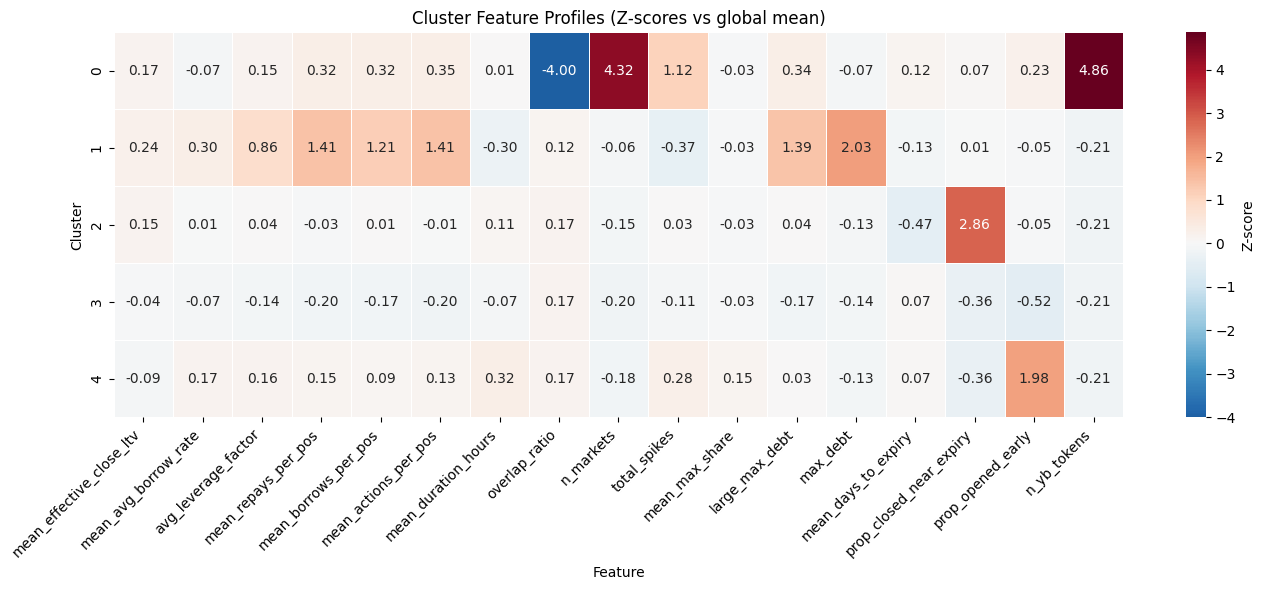


Cluster summaries (top features means)

--- Cluster 0 (n=48) ---
  n_yb_tokens                   :     2.0000  (z=+4.86) **
  prop_closed_near_expiry       :     0.1326  (z=+0.07)
  prop_opened_early             :     0.3019  (z=+0.23)
  n_markets                     :     2.1458  (z=+4.32) **
  overlap_ratio                 :     0.6420  (z=-4.00) **
  max_debt                      : 241604.8521  (z=-0.07)
  mean_actions_per_pos          :     4.8740  (z=+0.35)
  mean_repays_per_pos           :     2.3066  (z=+0.32)
  large_max_debt                :     0.5000  (z=+0.34)
  mean_borrows_per_pos          :     2.5674  (z=+0.32)
  total_spikes                  :   155.0625  (z=+1.12)
  avg_leverage_factor           :     1.9670  (z=+0.15)
  mean_duration_hours           :   939.4997  (z=+0.01)
  mean_days_to_expiry           :    21.9899  (z=+0.12)
  mean_avg_borrow_rate          :     0.0841  (z=-0.07)
  mean_effective_close_ltv      :     0.8147  (z=+0.17)
  mean_max_share            

In [63]:
users_features['large_max_debt'] = users_features['max_debt'] > 100_000
importance_df, cluster_means, zscore_df = interpret_clusters(metrics_hist[30]['labels'], users_features, selected_features, top_k=20)

### **GMM**

In [17]:
from sklearn.mixture import GaussianMixture
import numpy as np
import pandas as pd

def run_gmm(X_scaled, n_components, covariance_type='full', random_state=42):
    """
    Fit Gaussian Mixture Model and return hard cluster labels.

    Returns
    -------
    labels : np.ndarray
        Integer cluster labels (0 .. n_components-1).
    gmm : GaussianMixture
        Fitted model.
    """
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type=covariance_type,
        random_state=random_state,
        n_init=5,
        max_iter=200,
        reg_covar=1e-5
    )
    labels = gmm.fit_predict(X_scaled)
    return labels, gmm


def optimize_gmm(X_scaled, 
                 n_components_range=range(2, 15),
                 covariance_types=['full', 'tied', 'diag', 'spherical'],
                 random_state=42):
    """
    Grid search over number of components and covariance type using BIC.
    
    Returns
    -------
    best_labels : np.ndarray
    best_model : GaussianMixture
    results_df : pd.DataFrame
        Table with BIC, AIC, and silhouette for each parameter combination.
    """
    from sklearn.metrics import silhouette_score
    results = []
    best_bic = np.inf
    best_model = None
    best_labels = None
    best_params = None

    for k in n_components_range:
        for cov in covariance_types:
            gmm = GaussianMixture(
                n_components=k,
                covariance_type=cov,
                random_state=random_state,
                n_init=3,          # faster search
                max_iter=150,
                reg_covar=1e-5
            )
            labels = gmm.fit_predict(X_scaled)
            bic = gmm.bic(X_scaled)
            aic = gmm.aic(X_scaled)
            if len(np.unique(labels)) > 1:
                sil = silhouette_score(X_scaled, labels)
            else:
                sil = -1
            results.append({
                'n_components': k,
                'covariance_type': cov,
                'BIC': bic,
                'AIC': aic,
                'Silhouette': sil
            })
            if bic < best_bic:
                best_bic = bic
                best_model = gmm
                best_labels = labels
                best_params = (k, cov)
    
    results_df = pd.DataFrame(results).sort_values('BIC')
    print(f"Best parameters: n_components={best_params[0]}, covariance_type={best_params[1]}")
    print(f"Best BIC = {best_bic:.2f}")
    return best_labels, best_model, results_df


In [20]:
# gmm_labels, gmm_clusterer = run_gmm(X_scaled, 8, covariance_type='diag')
gmm_labels, best_gmm_model, gmm_results_df = optimize_gmm(X_scaled, n_components_range=(4, 5, 6, 7, 8, 9, 10), covariance_types=['diag'])

Best parameters: n_components=10, covariance_type=diag
Best BIC = -93898.70


In [21]:
gmm_results_df

,n_components,covariance_type,BIC,AIC,Silhouette
6,10,diag,-93898.696635,-96319.442075,0.097330
3,7,diag,-88209.667496,-89902.571880,0.084790
4,8,diag,-82362.861423,-84298.379493,0.133623
5,9,diag,-79942.448539,-82120.580294,0.094313
2,6,diag,-75199.583454,-76649.874152,0.098358
1,5,diag,-64334.455644,-65542.132657,0.129388
0,4,diag,-58286.165487,-59251.228814,0.180273


In [40]:
calc_clustering_quality(gmm_labels, X_scaled)

{'n_clusters': 5,
 'noise_ratio': 0.0,
 'silhouette': 0.13078789545921443,
 'davies_bouldin': 2.4391717337166994,
 'calinski_harabasz': 154.62917619057458}

/Users/yegortrussov/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Top important features (ANOVA F‑value)
                 feature     F_value       p_value
 prop_closed_near_expiry 1047.651139  0.000000e+00
           overlap_ratio  962.254153  0.000000e+00
max_concurrent_positions  407.694057  0.000000e+00
    mean_actions_per_pos  298.248651 1.591108e-285
    mean_borrows_per_pos  281.377474 3.446423e-274
             n_positions  276.636989 6.158184e-271
       prop_opened_early  201.127058 1.298886e-214
      n_collateral_types  178.086966 1.836736e-195
     mean_repays_per_pos  171.389030 1.077327e-189
     avg_leverage_factor  154.548801 9.256124e-175
      n_loan_asset_types  138.432125 7.517828e-160
       debtors_rank_ever  130.616055 2.186456e-152
             n_yb_tokens  106.360183 3.604114e-128
          large_max_debt   65.550511  2.646809e-83
                max_debt   40.376432  1.361447e-52
            total_spikes   26.467527  1.608278e-34
     mean_duration_hours   11.425795  3.231984e-14
     mean_days_to_expiry   10.228965  1.366

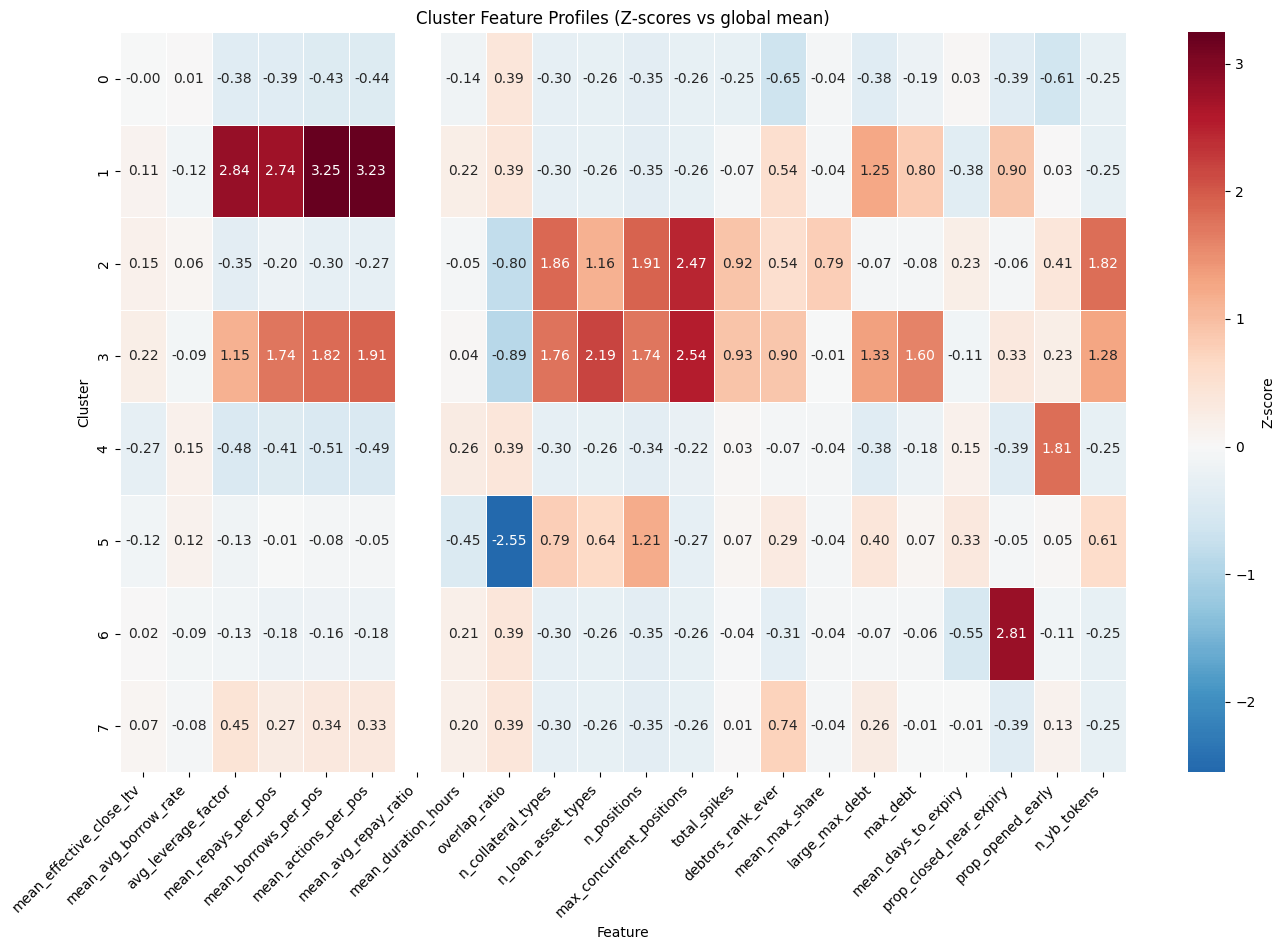


Cluster summaries (top features means)

--- Cluster 0 (n=609) ---
  prop_closed_near_expiry       :     0.0000  (z=-0.39)
  overlap_ratio                 :     1.0000  (z=+0.39)
  max_concurrent_positions      :     2.0000  (z=-0.26)
  mean_actions_per_pos          :     1.9787  (z=-0.44)
  mean_borrows_per_pos          :     0.9491  (z=-0.43)
  n_positions                   :     2.0000  (z=-0.35)
  prop_opened_early             :     0.0000  (z=-0.61)
  n_collateral_types            :     1.0000  (z=-0.30)
  mean_repays_per_pos           :     1.0296  (z=-0.39)
  avg_leverage_factor           :     1.2521  (z=-0.38)
  n_loan_asset_types            :     1.0000  (z=-0.26)
  debtors_rank_ever             :     0.0000  (z=-0.65)
  n_yb_tokens                   :     1.0000  (z=-0.25)
  large_max_debt                :     0.0000  (z=-0.38)
  max_debt                      : 68196.5946  (z=-0.19)
  total_spikes                  :    42.5977  (z=-0.25)
  mean_duration_hours           :   7

In [49]:
importance_df, cluster_means, zscore_df = interpret_clusters(gmm_labels, users_features, selected_features, top_k=20)

HDBSCAN Clustering Evaluation
  Number of clusters (excluding noise): 8
  Noise points: 0 (0.0%)
  Cluster sizes:
    Cluster 0: 609 users (37.5%)
    Cluster 1: 42 users (2.6%)
    Cluster 2: 77 users (4.7%)
    Cluster 3: 73 users (4.5%)
    Cluster 4: 154 users (9.5%)
    Cluster 5: 153 users (9.4%)
    Cluster 6: 141 users (8.7%)
    Cluster 7: 373 users (23.0%)
  Silhouette Score (core): 0.1336
  Davies-Bouldin Score (core): 2.1335
  Calinski-Harabasz Score (core): 147.56


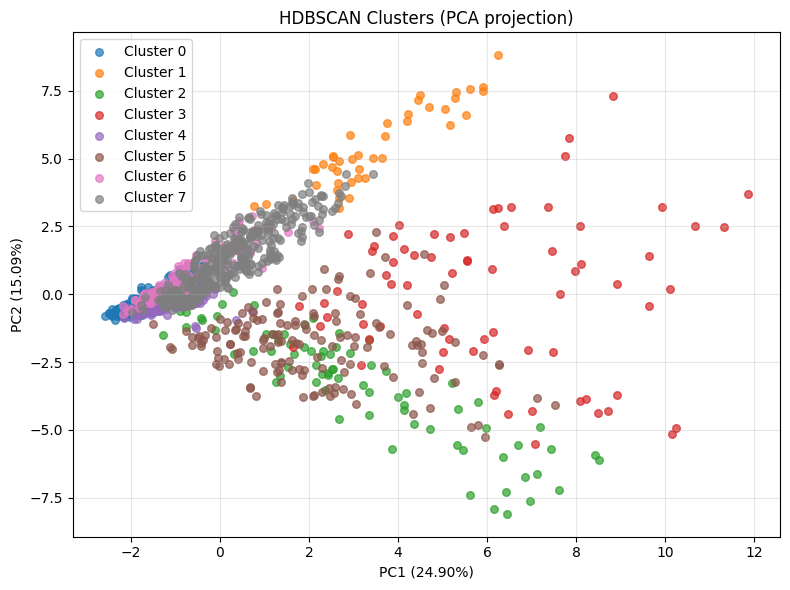

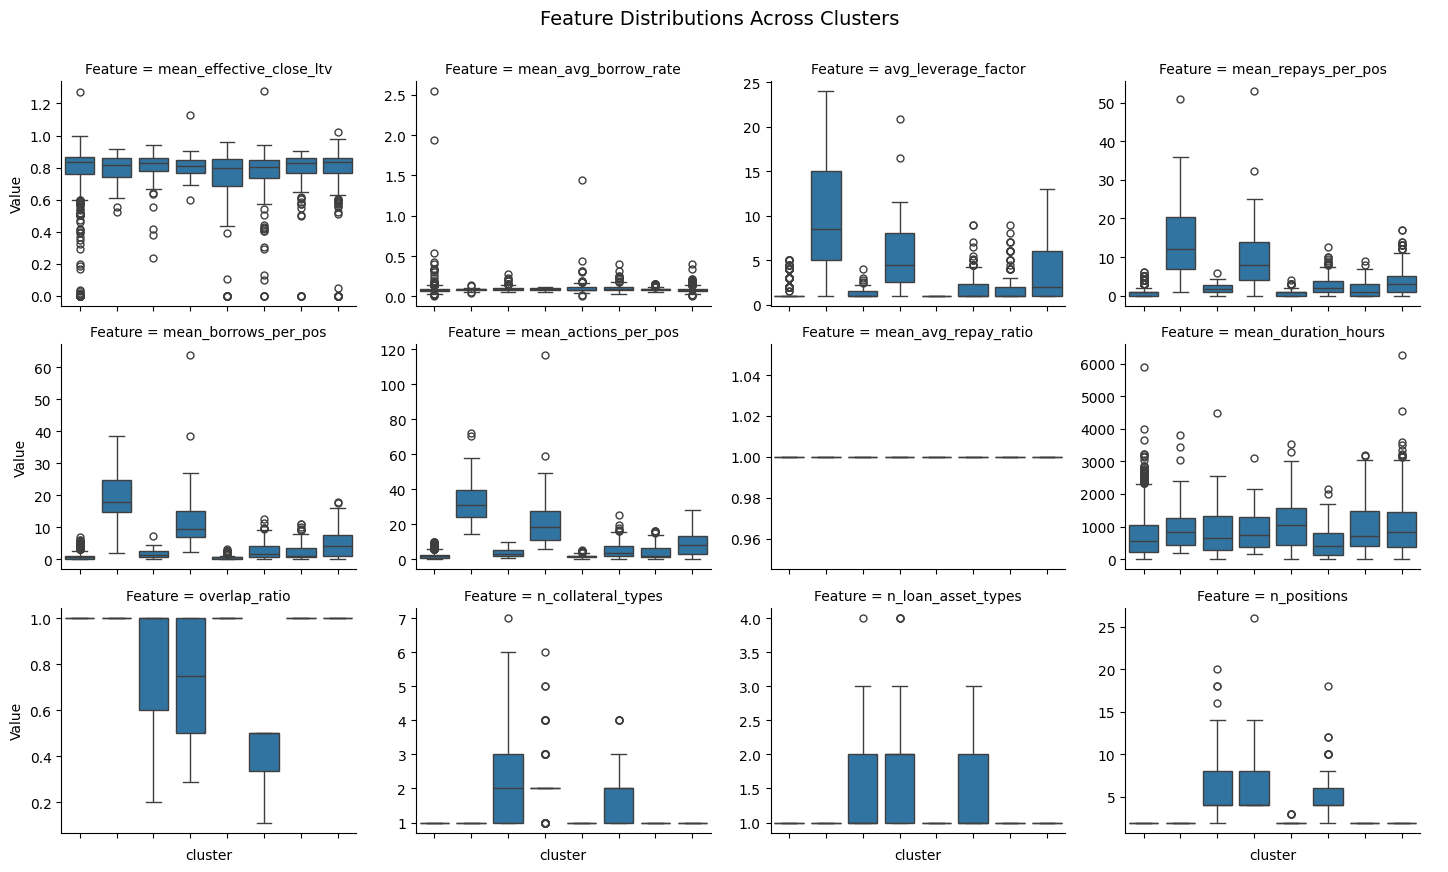

,user_address,n_positions,n_markets,n_collateral_types,n_loan_asset_types,mean_open_debt,median_open_debt,mean_max_debt,median_max_debt,max_debt,median_max_ltv,mean_avg_borrow_rate,mean_duration_hours,median_duration_hours,mean_time_to_first_action,median_time_to_first_action,avg_leverage_factor,mean_repays_per_pos,median_repays_per_pos,total_repays,mean_borrows_per_pos,median_borrows_per_pos,total_borrows,mean_actions_per_pos,median_actions_per_pos,total_actions,mean_avg_repay_ratio,was_active_during_spike_any,debtors_rank_ever,mean_concentration_hhi,total_spikes,prop_closed,prop_high_ltv_open,std_max_ltv,mean_max_share,prop_debtors_rank,mean_utilization_open,mean_total_liquidity_open,mean_days_to_expiry,median_days_to_expiry,prop_closed_near_expiry,prop_opened_early,n_yb_tokens,mean_effective_close_ltv,median_effective_close_ltv,max_concurrent_positions,overlap_ratio,std_avg_borrow_rate,large_max_debt,cluster
0,0x002AFa1e35cE85272aAE5e0d7Ab541DFd442B667,2,1,1,1,1.579708e+04,1.579708e+04,1.579708e+04,1.579708e+04,1.579708e+04,0.851547,0.099236,662.270000,662.270000,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True,False,0.307859,36.0,1.0,1.0,0.0,0.000077,0.0,0.890883,2.527534e+07,9.0,9.0,0.0,0.0,1,0.843812,0.843812,2,1.0,0.0,False,0
1,0x00896485a15c549AA6948c7430bef1f02f752300,2,1,1,1,1.599523e+04,1.599523e+04,1.599523e+04,1.599523e+04,1.599523e+04,0.804415,0.094134,297.676667,297.676667,143.663333,143.663333,1.0,1.0,1.0,2.0,0.5,0.5,1.0,1.5,1.5,3.0,1.0,False,False,0.700000,0.0,1.0,0.0,0.0,0.070776,0.0,0.918699,2.000004e+04,50.0,50.0,0.0,1.0,1,0.803997,0.803997,2,1.0,0.0,False,4
2,0x008E5d9ea233Dfb9AB48098d6E98E14374030c15,2,1,1,1,1.689294e+05,1.689294e+05,9.847084e+05,9.847084e+05,9.847084e+05,0.857420,0.057556,1837.820000,1837.820000,0.045000,0.045000,14.0,29.0,29.0,58.0,14.5,14.5,29.0,43.5,43.5,87.0,1.0,True,True,1.000000,54.0,1.0,1.0,0.0,0.622500,1.0,0.696064,7.598600e+06,-1.0,-1.0,0.0,0.0,1,0.628643,0.628643,2,1.0,0.0,False,1
3,0x00A2913501C4B09B92b825dC8A2937eFDaD9953b,2,1,1,1,4.999480e+05,4.999480e+05,7.298244e+06,7.298244e+06,7.298244e+06,0.797200,0.145384,1755.310000,1755.310000,10.883333,10.883333,1.0,8.0,8.0,16.0,8.0,8.0,16.0,16.0,16.0,32.0,1.0,True,True,1.000002,154.0,1.0,0.0,0.0,0.498799,1.0,0.934287,9.279599e+05,-2.0,-2.0,0.0,1.0,1,0.718067,0.718067,2,1.0,0.0,True,7
4,0x00B8dF76c223eb4b05123389330b4afD157152b8,2,1,1,1,1.238581e+06,1.238581e+06,4.760966e+06,4.760966e+06,4.760966e+06,0.890971,0.052546,437.876667,437.876667,0.076667,0.076667,4.0,5.0,5.0,10.0,4.5,4.5,9.0,9.5,9.5,19.0,1.0,True,True,0.688498,20.0,1.0,1.0,0.0,1.741203,1.0,0.368415,4.687495e+06,-1.0,-1.0,0.0,0.0,1,0.854283,0.854283,2,1.0,0.0,True,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617,0xfc9803f19a667Ac43E13fC57405f9fDCdaC54747,2,1,1,1,1.299721e+04,1.299721e+04,1.499973e+04,1.499973e+04,1.499973e+04,1.272642,0.075387,387.983333,387.983333,248.103333,248.103333,1.0,1.0,1.0,2.0,2.0,2.0,4.0,3.0,3.0,6.0,1.0,True,False,0.616618,16.0,1.0,1.0,0.0,0.002204,0.0,0.891826,8.900126e+05,NaN,NaN,0.0,0.0,1,1.272642,1.272642,2,1.0,0.0,False,0
1618,0xfcB2f00cF544E934E2f163c2593c7CE3eF7fFA9D,2,1,1,1,1.399968e+05,1.399968e+05,1.399968e+05,1.399968e+05,1.399968e+05,0.867930,0.061129,132.886667,132.886667,66.413333,66.413333,1.0,2.0,2.0,4.0,0.5,0.5,1.0,2.5,2.5,5.0,1.0,True,True,0.949284,16.0,1.0,1.0,0.0,0.317168,1.0,0.867609,6.735403e+04,135.0,135.0,0.0,0.0,1,0.867930,0.867930,2,1.0,0.0,False,7
1619,0xfd1fA2C22F65649AE02188a33F286f22bcFCd225,2,1,1,1,4.490104e+04,4.490104e+04,9.136159e+04,9.136159e+04,9.136159e+04,0.903065,0.170632,695.083333,695.083333,17.473333,17.473333,1.0,0.0,0.0,0.0,1.5,1.5,3.0,1.5,1.5,3.0,1.0,True,False,0.850482,16.0,1.0,1.0,0.0,0.001948,0.0,0.850424,7.803732e+06,66.0,66.0,0.0,0.0,1,0.883420,0.883420,2,1.0,0.0,False,0
1620,0xff17d5A9f7dB38A1384CF0ce1c81b880D17dB838,2,1,1,1,5.29

In [50]:
evaluate_clustering(gmm_labels, X_scaled, users_features, selected_features)

### **Cluster users analisys**

In [195]:
df_with_clusters = df.merge(user_clusters_to_save[["user_address", "hdbscan_cluster"]], how='left', on='user_address') \
    .rename(columns={"hdbscan_cluster": "cluster"})
df_with_clusters['market_type'] = df_with_clusters.apply(lambda r : "crypto" if r['market'] in CRYPTO_MARKETS else ("yb" if r['market'] in YB_TOKENS else 'pt'), axis=1)
df_with_clusters.head(3)

,user_address,market,open_timestamp,open_datetime,open_debt,open_ltv,open_borrow_rate,leverage_factor,close_timestamp,close_datetime,close_debt,close_ltv,close_borrow_rate,max_debt,max_ltv,n_repays,n_borrows,is_closed,duration_hours,time_to_first_action,avg_time_between_actions,max_time_between_actions,n_actions_total,avg_repay_ratio,was_active_during_spike,num_spikes_experienced,closed_during_spike,position_size_share_open,position_size_share_max,debtors_rank,utilization_open,total_debt_open,total_liquidity_open,concentration_hhi_open,top3_share_open,avg_borrow_rate_position,position_index,collateral_asset,loan_asset,cluster,market_type
0,0xf8b9D83574574A345c32905a2A62D1d84650A0Ae,base_cbbtc_usdc_full,1726217705,2024-09-13 08:55:05,1.0,0.172022,0.041709,1,1.764177e+09,2025-11-26 17:05:11,1.000000,0.172022,0.041709,1.0,0.172022,0,0,False,10544.168333,10544.168333,10544.168333,10544.168333,0,1,False,0,False,NaN,NaN,False,0.000000,0.0,0.000000,NaN,NaN,0.041709,0,cbbtc,usdc,-1,crypto
1,0xf8b9D83574574A345c32905a2A62D1d84650A0Ae,base_cbbtc_usdc_full,1726217705,2024-09-13 08:55:05,1.0,0.172022,0.041709,1,1.764177e+09,2025-11-26 17:05:11,1.000000,0.172022,0.041709,1.0,0.172022,0,0,False,10544.168333,10544.168333,10544.168333,10544.168333,0,1,False,0,False,NaN,NaN,False,0.000000,0.0,0.000000,NaN,NaN,0.041709,1,cbbtc,usdc,-1,crypto
2,0x9aE9A52Eb952aE82c592e109f04C844B94e9975a,base_cbbtc_usdc_full,1726241775,2024-09-13 15:36:15,150000.0,0.700799,0.041616,1,1.727133e+09,2024-09-23 23:02:29,-8.357457,-0.231041,0.026968,150000.0,0.700799,3,0,True,247.437222,12.058889,98.025000,195.958889,3,1,False,0,False,150000.0,150000.0,False,0.983789,1.0,0.016478,NaN,NaN,0.030925,2,cbbtc,usdc,-1,crypto


In [159]:
df_with_clusters.shape, df.shape

((109479, 40), (109479, 39))

In [198]:
for c in sorted(df_with_clusters['cluster'].unique()):
    cl_users = df_with_clusters[df_with_clusters['cluster'] == c]
    print(f"{c} - {cl_users['market_type'].value_counts().to_dict()}")

-1 - {'crypto': 11972, 'yb': 5758, 'pt': 2824}
0 - {'crypto': 902, 'yb': 138, 'pt': 48}
1 - {'pt': 200, 'yb': 136, 'crypto': 28}
2 - {'crypto': 1036}
3 - {'pt': 568, 'yb': 500, 'crypto': 8}
4 - {'yb': 2142, 'crypto': 92, 'pt': 28}
5 - {'crypto': 694, 'yb': 464, 'pt': 200}
6 - {'crypto': 24958, 'yb': 76, 'pt': 6}
7 - {'crypto': 31170, 'yb': 458, 'pt': 20}
8 - {'crypto': 12500, 'yb': 370, 'pt': 26}


In [202]:
for m in df_with_clusters['market_type'].unique():
    cl_users = df_with_clusters[df_with_clusters['market_type'] == m]
    print(f"{m} - {cl_users['cluster'].value_counts().sort_index().to_dict()}")

crypto - {-1: 11972, 0: 902, 1: 28, 2: 1036, 3: 8, 4: 92, 5: 694, 6: 24958, 7: 31170, 8: 12500}
pt - {-1: 2824, 0: 48, 1: 200, 3: 568, 4: 28, 5: 200, 6: 6, 7: 20, 8: 26}
yb - {-1: 5758, 0: 138, 1: 136, 3: 500, 4: 2142, 5: 464, 6: 76, 7: 458, 8: 370}


In [206]:
cl_users = df_with_clusters[df_with_clusters['cluster']==3]
# df_with_clusters[df_with_clusters['cluster']==1]['user_address'].nunique(), df_with_clusters[df_with_clusters['cluster']==1].shape
cl_users['max_debt'].describe()

cl_users[[
    'user_address',
    "market",
    "max_debt",
    "open_ltv",
    "close_ltv",
    "duration_hours",
    "was_active_during_spike",
]]

,user_address,market,max_debt,open_ltv,close_ltv,duration_hours,was_active_during_spike
77386,0x00e9eaF42eD86610Df9510d123Cf4d7a5D19FAd4,eth_cbbtc_usdc,69499.305000,0.823325,0.666573,4512.090000,True
77387,0x00e9eaF42eD86610Df9510d123Cf4d7a5D19FAd4,eth_cbbtc_usdc,69499.305000,0.823325,0.666573,4512.090000,True
77544,0x38ac78C059314F933DC7Bd348Fc1E7F11c33c002,eth_cbbtc_usdc,8192.385548,0.819027,0.819027,7959.403333,True
77545,0x38ac78C059314F933DC7Bd348Fc1E7F11c33c002,eth_cbbtc_usdc,8192.385548,0.819027,0.819027,7959.350000,True
79068,0x0cFaEc112c30A5A392eb633daAe5231Aa3d7623F,eth_wbtc_usdc,11011.000000,0.805381,0.735788,2471.213333,True
...,...,...,...,...,...,...,...
97249,0x1E6315Ba6AfD1B04f9c1A1629517BEA60449e7C3,eth_wstusr_usdc,222779.840179,0.867569,0.864510,136.190000,True
97254,0x4fe8810d083ca126D65A9397d462b824AA6Ab799,eth_wstusr_usdc,176327.643213,0.857941,0.000000,102.436667,True
97255,0x4fe8810d083ca126D65A9397d462b824AA6Ab799,eth_wstusr_usdc,176327.643213,0.857941,0.000000,102.436667,True
97276,0xd529b4Bdd387f6dc09008244a9d86ACC2FF7718C,eth_wstusr_usdc,21493.765000,0.859266,0.850811,771.656667,True


In [207]:
cl_users['market'].value_counts()

market
eth_usr_usdc                       130
eth_slvlusd_usdc                   124
eth_PT-csUSDL-31JUL2025_usdc       102
eth_PT-USDe-25SEP2025_usdc          66
eth_wstusr_usdc                     64
eth_PT-stcUSD-29JAN2026_usdc        58
eth_PT-USDe-25SEP2025_usdt          52
eth_PT-lvlUSD-29MAY2025_usdc        46
eth_PT-slvlUSD-25SEP2025_usdc       42
eth_rlp_usdc                        40
eth_mhyper_usdc                     38
eth_PT-wstUSR-27MAR2025_usr         36
eth_usd0++_usdc                     32
eth_PT-wstUSR-25SEP2025_usdc        30
eth_PT-USDe-31JUL2025_dai           30
eth_PT-RLP-4SEP2025_usdc            26
eth_csusdl_usdc                     20
eth_PT-mHYPER-20NOV2025_usdc        18
eth_fxsave_usdc                     18
eth_siusd_usdc                      14
eth_PT-USDe-27MAR2025_dai           14
eth_PT-slvlUSD-29MAY2025_usdc       12
eth_PT-USDe-27NOV2025_usds          10
eth_syrupusdc_usdc                   8
eth_PT-USD0++-27MAR2025_usdc         8
eth_usde_dai      

In [ ]:
susp_opens = df.groupby(["user_address", "open_timestamp", "market"])['open_debt'].count()
susp_opens[susp_opens > 2].reset_index()['market'].value_counts()
susp_opens.value_counts()

open_debt
2     48245
1      1068
11     1028
3       125
4        50
19        2
Name: count, dtype: int64

market
eth_PT-reUSD-25JUN2026_usdc        1025
base_cbbtc_usdc_full                 82
base_wbtc_usdt                       15
eth_wbtc_usdt                        15
eth_wbtc_usdc                        10
eth_wsteth_usdc                       9
eth_PT-USD0++-27MAR2025_usdc          6
eth_wsteth_usdt                       6
eth_weth_usdt                         5
eth_usd0++_usdc                       5
eth_PT-sNUSD-5MAR2026_usdc            5
eth_cbbtc_usdc                        3
eth_usde_dai                          3
eth_PT-USDe-25SEP2025_dai             2
eth_PT-RLP-4SEP2025_usdc              2
eth_PT-wstUSR-25SEP2025_usdc          2
eth_susde_pyusd                       2
eth_PT-syrupUSDC-28AUG2025_usdc       2
eth_wstusr_usdc                       1
eth_rlp_usdc                          1
eth_PT-USDe-25SEP2025_usdc            1
eth_usr_usdc                          1
eth_PT-slvlUSD-25SEP2025_usdc         1
eth_PT-slvlUSD-29MAY2025_usdc         1
Name: count, dtype: int64